In [1]:
# libraries for data loading and plotting
import matplotlib.pyplot as plt
import json
import pandas as pd

In [5]:
# load augmentation assessments for ner
with open("augmentations_ner/eval_results/metrics_datasetsize.json", "r") as f:
    metrics_dataset_size = json.load(f)
with open("augmentations_ner/eval_results/metrics_augmentations.json", "r") as f:
    metrics_augmentations_ner = json.load(f)

# load oversampling assessments for stance classification
with open("oversampling_stance/eval_results/metrics_original_data.json", "r") as f:
    metrics_original_data = json.load(f)
with open("oversampling_stance/eval_results/metrics_aug_only_negative.json", "r") as f:
    metrics_only_negative = json.load(f)
with open("oversampling_stance/eval_results/metrics_aug_minority_classes.json", "r") as f:
    metrics_minority_classes = json.load(f)
with open("oversampling_stance/eval_results/metrics_aug_prop.json", "r") as f:
    metrics_proportional = json.load(f)

# combine metrics in one dictionary
metrics_bound = {"original_data": metrics_original_data,
                 "only_negative": metrics_only_negative,
                 "minority_classes": metrics_minority_classes,
                 "proportional": metrics_proportional}

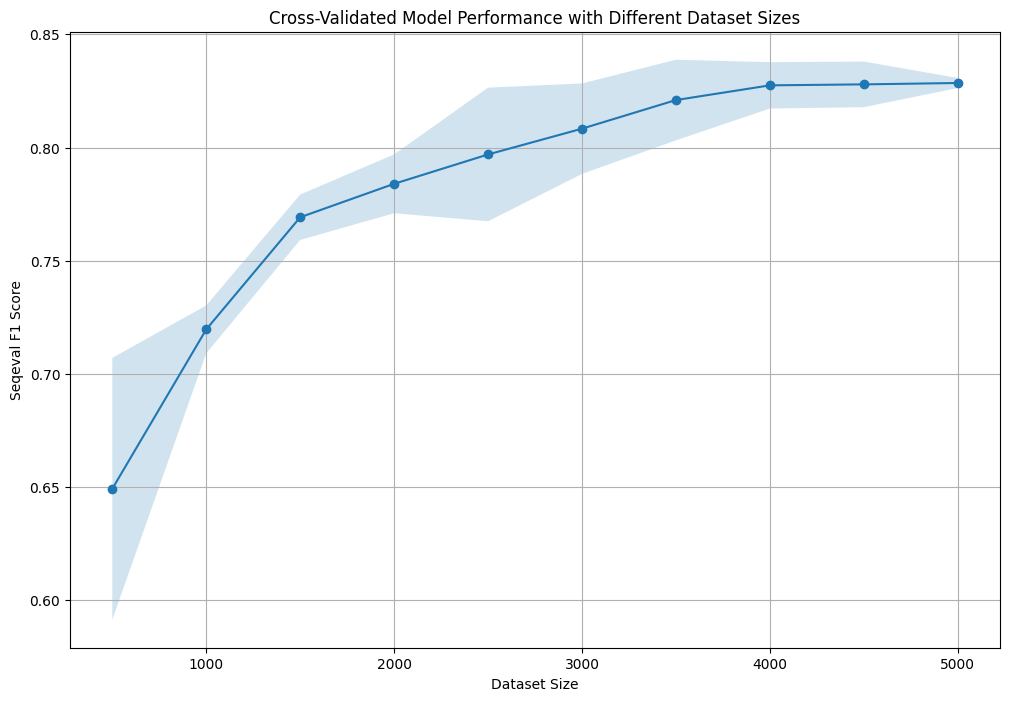

In [6]:
# Extract fields from dictionary results
def extract(values):
    sizes = [d["dataset_size"] for d in values]
    means = [d["mean_seqeval"] for d in values]
    lower = [d["ci_lower"] for d in values]
    upper = [d["ci_upper"] for d in values]
    return sizes, means, lower, upper

sizes, means, lower, upper = extract(metrics_dataset_size)

plt.figure(figsize=(12,8))

# Non-augmented
plt.plot(sizes, means, marker='o')
plt.fill_between(sizes, lower, upper, alpha=0.2)
plt.title("Cross-Validated Model Performance with Different Dataset Sizes")
plt.xlabel("Dataset Size")
plt.ylabel("Seqeval F1 Score")
plt.grid(True)
plt.show()

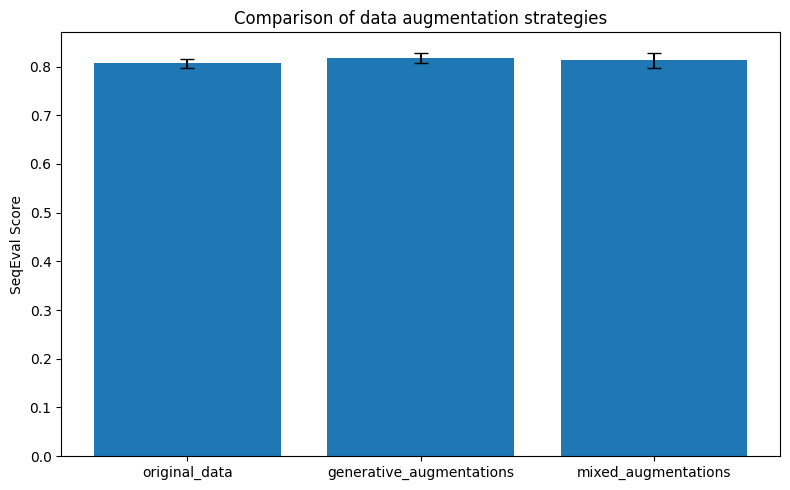

In [7]:
# Convert to DataFrame
rows = []
for method, stats in metrics_augmentations_ner[0].items():
    rows.append({
        "method": method,
        "mean": stats["mean_seqeval"],
        "error": stats["mean_seqeval"] - stats["ci_lower"]
    })

df = pd.DataFrame(rows)

# Plot
plt.figure(figsize=(8,5))
plt.bar(df["method"], df["mean"], yerr=df["error"], capsize=5)
plt.ylabel("SeqEval Score")
plt.title("Comparison of data augmentation strategies")

plt.tight_layout()
plt.show()

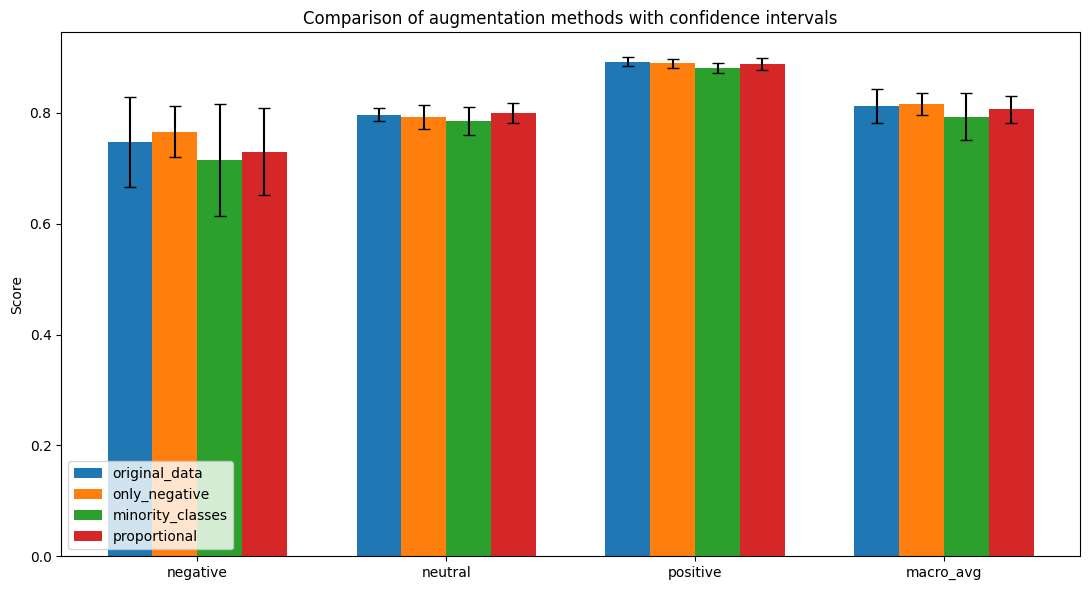

In [9]:
# turn into a wide df
rows = []

for method, entries in metrics_bound.items():
    entry = entries[0]                     # each method has a list with one dict
    for label, stats in entry.items():
        rows.append({
            "method": method,
            "label": label,
            "mean": stats["mean"],
            "lower": stats["lower"],
            "upper": stats["upper"],
            "error": stats["mean"] - stats["lower"]
        })

df = pd.DataFrame(rows)

labels = df["label"].unique()
methods = df["method"].unique()

x = range(len(labels))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 6))

for i, method in enumerate(methods):
    subset = df[df["method"] == method]
    ax.bar(
        [p + i * width for p in x],
        subset["mean"],
        width=width,
        yerr=subset["error"],
        capsize=4,
        label=method
    )

ax.set_xticks([p + (len(methods)-1) * width / 2 for p in x])
ax.set_xticklabels(labels)
ax.set_ylabel("Score")
ax.set_title("Comparison of augmentation methods with confidence intervals")
ax.legend()

plt.tight_layout()
plt.show()